In [77]:
#installations + imports
%pip install -U emcee corner

import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner

Note: you may need to restart the kernel to use updated packages.


--> Goal is to obtain many samples that each represent a reasonable parameter combo + their uncertainties and correlations

In [78]:
# Create x-data
x = np.linspace(0, 10, 30)

# True parameter values
slope_true = 1.5
intercept_true = 4.0
uncertainty_true = 1.0

# Generate y-data
rng_data = np.random.default_rng(42)

y = slope_true * x + intercept_true
y = y + rng_data.normal(
    0,
    uncertainty_true,
    len(x)
)

# Uncertainty for every point
err = np.ones_like(y) * uncertainty_true

In [79]:
# keeping this from the tutorial
def loglikelihood(p, x, y, e):
    slope = p[0]
    intercept = p[1]

    model = slope * x + intercept #predicted y-axis
    chisq = np.sum((y - model)**2 / e**2) 
    #measures disagreement between the data and model

    return -0.5 * chisq # Higher log-likelihood means a better fit

# defining a posterior fn
def log_probability(p, x, y, e):
    return loglikelihood(p, x, y, e)
# want emcee to smaple the same likelihood as tutorial

#form tutorial:
# all_log_likelihoods = np.ones(nlink)
# startpos = np.array([1, 1])

# for i in range(nlink):

# replacing loop:
# number of parameters: slope and intercept
ndim = 2

# number of simultaneously runnign chains
nwalkers = 32

# number of steps taken by each walker
nsteps = 5000

# same starting point used in oiginal tutorial
startpos = np.array([1.0, 1.0]) # [slope, intercept]

# start walkers near inital condition
rng = np.random.default_rng(42) #random number generator stored in rng

initial_positions = (
    startpos # + 1 basically
    + 1e-2 * rng.standard_normal((nwalkers, ndim)) #makes random offsets smaller
    #rng.standard_normal makes pairs of random numbers
)

#making sampler
sampler = emcee.EnsembleSampler(
    nwalkers, # 32 walkers
    ndim, # number of free parameters (2) which are the slope + intercept
    log_probability, #how plausible each pair is
    args=(x, y, err) #passes data back up to log+probability
)

#run mcmc
sampler.run_mcmc(
    initial_positions, #where walkers begin
    nsteps, # how many steps to take (whatever nsteps is defined as above)
    progress=True # progress bar #cool
)

#retrieve chains
chain = sampler.get_chain()

print(chain.shape) #should be (nsteps, nwalkers, ndim)

You must install the tqdm library to use progress indicators with emcee


(5000, 32, 2)


## Trace Plots

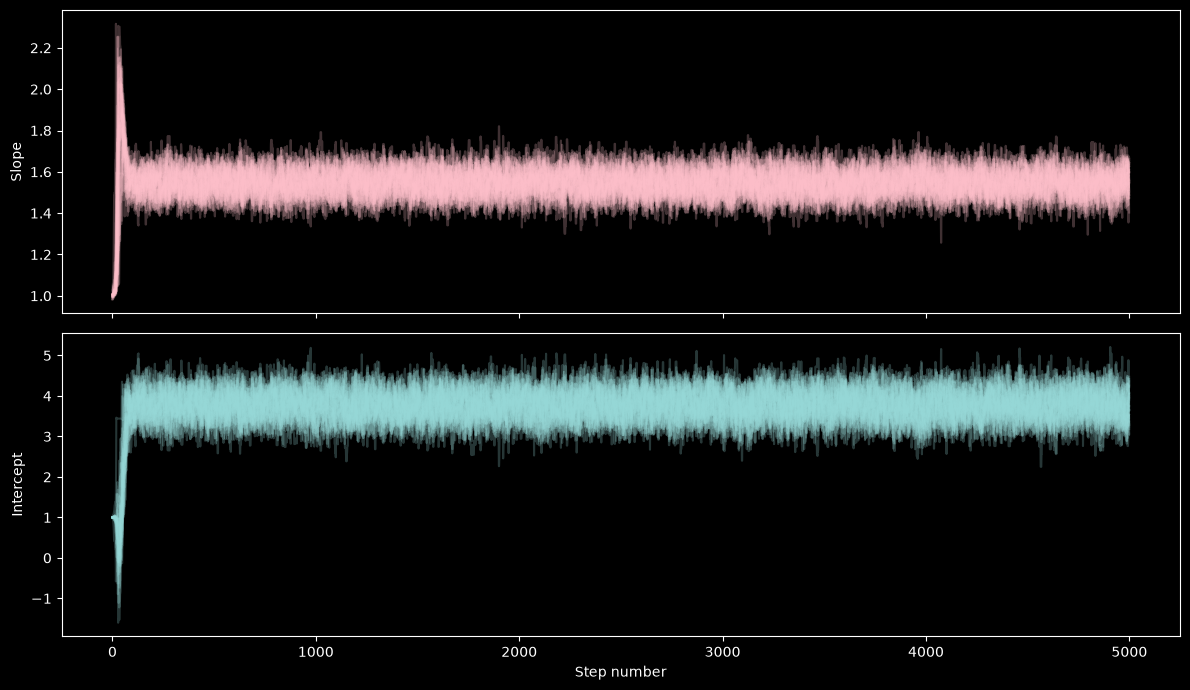

In [80]:
# implementing the additional walker dimension in emcee because
# the original chain was shaped as (number of steps, number of parameters)

labels = ["Slope", "Intercept"]
colors = ["pink", "#98DAD9"]

fig, axes = plt.subplots(
    2, #requests two subplots
    figsize=(12,7),
    sharex=True #plots have same step-number axis
)
# axes[0] slope plot
# axes[1] intercept plot

for i in range(ndim): 
    #looping over model parameters (slopt (i=0) and intercept (i=1))
    axes[i].plot(
        chain[:, :, i], #[elects every MCMC step, select every walker, select one parameter]
        color=colors[i],
        alpha=0.25 #opacity of line, looks funky when fully opaque
        )
        #plots MCMC history for i
        #chain has shape (steps, walkers, parameters) now
    axes[i].set_ylabel(labels[i]) #label via corresponding items for labels above


axes[-1].set_xlabel("Step number") #adds x-axes to second plot (corresponds to both plots though)

plt.tight_layout() #adjusts spacing
plt.show()

## What trace plots tell us...
- Whether walkers moved away from their starting positions
- Whether the walkers reacher the same posterior position
- Wheter the chains appear stable
- Whether the walkers are mixing instead of remaining stuck

## Mean Acceptance Fraction
Each number is the fraction of proposed moves that a particular walker accepted.

In [81]:
#acceptance fraction

mean_acceptance = np.mean(sampler.acceptance_fraction)
# sampler.acceptance_fraction returns one value for each walker

print("Mean Acceptance Fraction:", mean_acceptance)

Mean Acceptance Fraction: 0.7101062499999999


## Remove burn-in and flatten the walkers
Burn-in is the beginning portion of an MCMC run that you discard because the walkers are still moving away from their artificial starting positions toward the high-probability region.

- The early samples may still be strongly affected by that artificial starting position. Removing them prevents the starting guess from influencing the final results.

In [82]:
burn_in = 500 # number of initial steps to discard
# is there a good number of these to discard? 
# is there a "too much" limit? becuase in theory, removing more would
# make it more accurate + less affected by initial condition, right?

bchain = sampler.get_chain(
    #retreiving retained parameter samples
    discard=burn_in, #removes first 500 steps
    flat=True #combines walker + step dimensions
)

print(bchain.shape) #shows new dimensions

# example:
# before flattening: (4500, 32, 2)
# after flattening: (144000, 2) -> 32 * 4500 = 144000


(144000, 2)


## Autocorrelation

In [83]:
# Retrieve the chain from your original sampler
chain_linear = sampler.get_chain()

print("Chain shape:", chain_linear.shape)

Chain shape: (5000, 32, 2)


In [84]:
# Give the two-parameter sampler a clearer name
sampler_linear = sampler

# Retrieve the linear chain
chain_linear = sampler_linear.get_chain()

print("Chain shape:", chain_linear.shape)
# Expected: (5000, 32, 2)

# Integrated autocorrelation time for each parameter
tau_linear = sampler_linear.get_autocorr_time()

print("Slope autocorrelation time:", tau_linear[0])
print("Intercept autocorrelation time:", tau_linear[1])

# Choose burn-in as twice the largest autocorrelation time
burn_in_linear = int(np.ceil(2 * np.max(tau_linear)))

print("Burn-in:", burn_in_linear)

# Remove burn-in and combine steps/walkers
bchain_linear = sampler_linear.get_chain(
    discard=burn_in_linear,
    flat=True
)

print("Cleaned chain shape:", bchain_linear.shape)

Chain shape: (5000, 32, 2)
Slope autocorrelation time: 22.512566157058224
Intercept autocorrelation time: 41.39109276608838
Burn-in: 83
Cleaned chain shape: (157344, 2)


## New Trace Plots With New Burn-In

Burn-in: 83
Cleaned chain shape: (157344, 2)


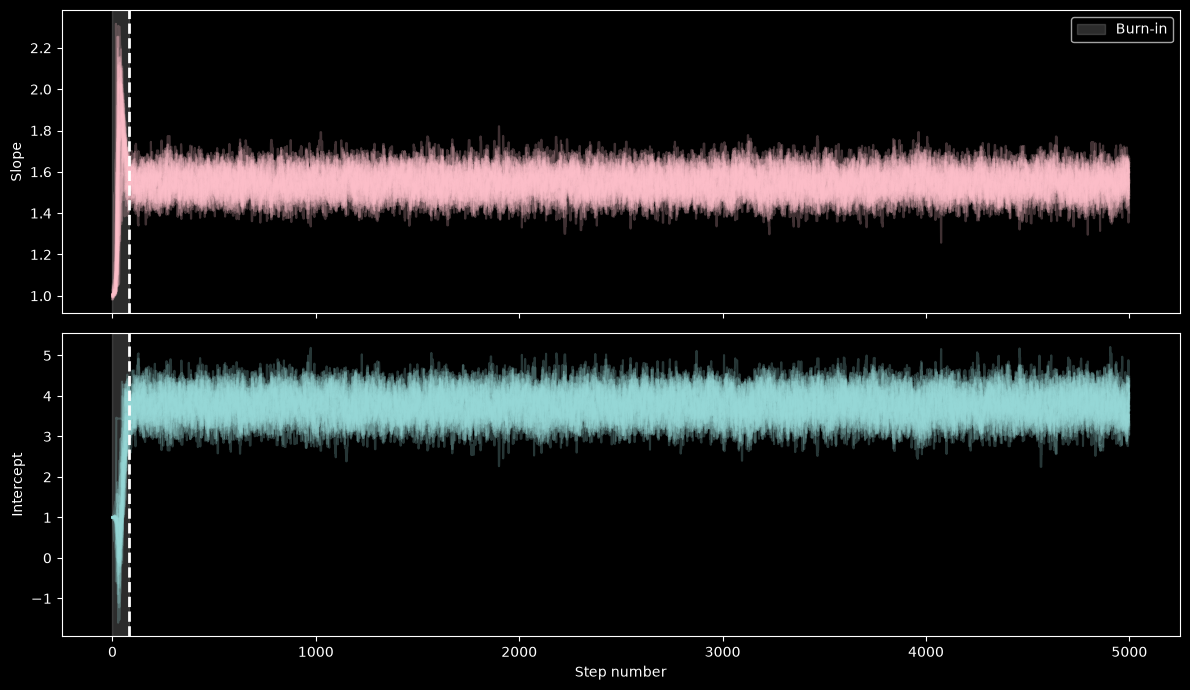

In [85]:
# Use the autocorrelation-based burn-in calculated above
burn_in = burn_in_linear

# Cleaned and flattened linear chain
bchain = sampler_linear.get_chain(
    discard=burn_in,
    flat=True
)

print("Burn-in:", burn_in)
print("Cleaned chain shape:", bchain.shape)

labels = ["Slope", "Intercept"]
colors = ["pink", "#98DAD9"]

fig, axes = plt.subplots(
    2,
    figsize=(12, 7),
    sharex=True
)

for i in range(2):
    axes[i].plot(
        chain_linear[:, :, i],
        color=colors[i],
        alpha=0.25
    )

    # Shade the discarded section
    axes[i].axvspan(
        0,
        burn_in,
        color="gray",
        alpha=0.35,
        label="Burn-in"
    )

    # Mark the burn-in cutoff
    axes[i].axvline(
        burn_in,
        color="white",
        linestyle="--",
        linewidth=2
    )

    axes[i].set_ylabel(labels[i])

axes[-1].set_xlabel("Step number")
axes[0].legend()

plt.tight_layout()
plt.show()

## Plotting marginalized distributions
The height of each bar shows how many posterior samples fall in that interval.
- Each histogram approximates the marginalized posterior distribution of one parameter.
- “Marginalized” means that when examining the slope distribution, uncertainty in the intercept has already been included, and vice versa.
- The peak shows the most commonly sampled region. The width represents parameter uncertainty.

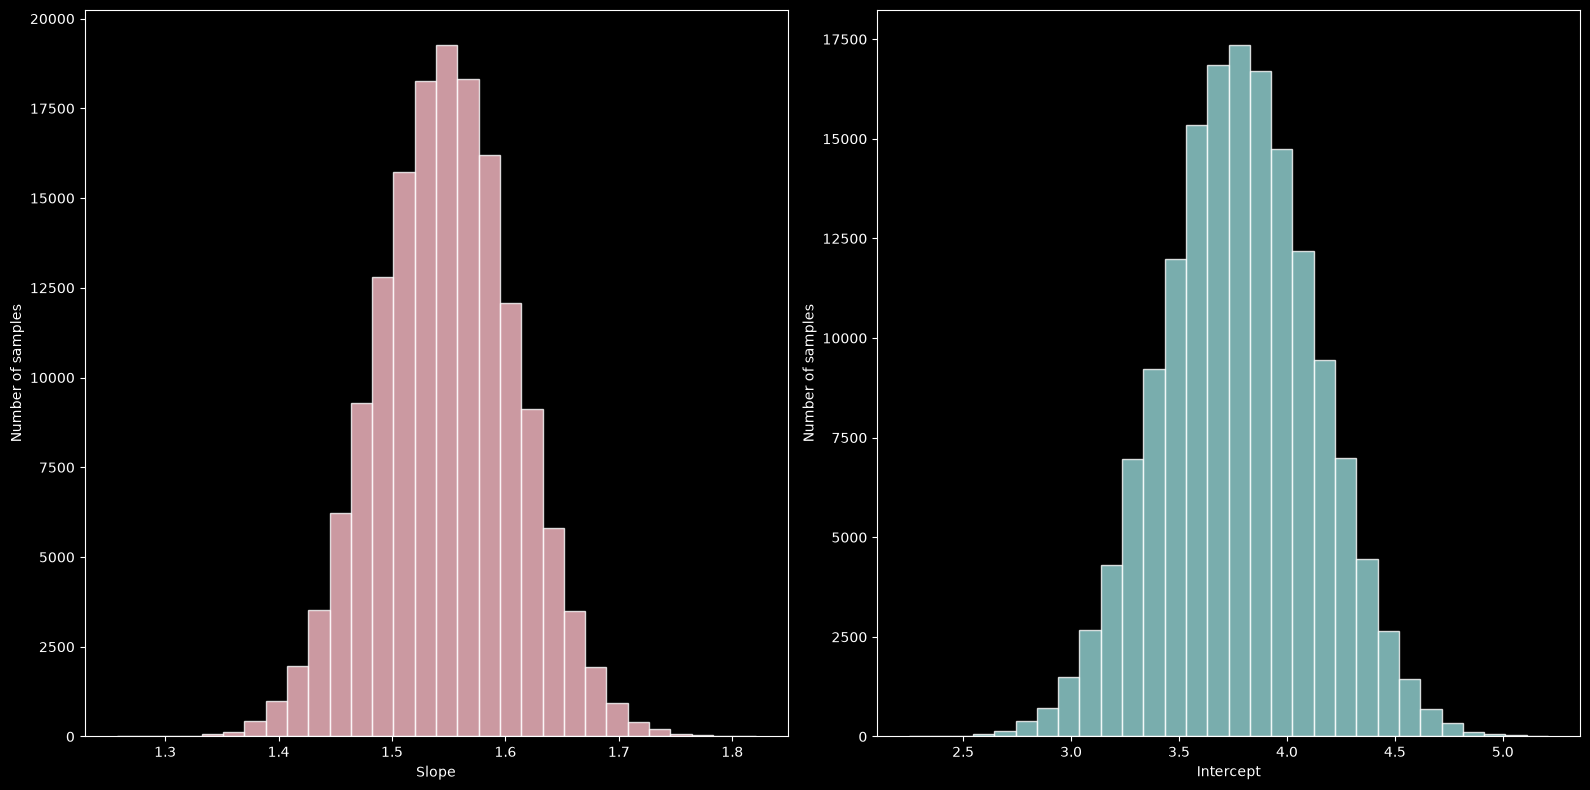

In [86]:
# FYI reusing the histogram code

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

#ax[0] is the slope histogram
#ax[1] is the intercept histogram

ax[0].set_ylabel("Number of samples")
ax[0].set_xlabel("Slope")
ax[1].set_ylabel("Number of samples")
ax[1].set_xlabel("Intercept")

ax[0].hist(
    bchain[:, 0], 
    bins=30,
    color="pink",
    edgecolor="white",
    alpha=0.8) # creates histogram of slope samples
# bchain[:, 0] selects every row from the slope column (0)

ax[1].hist(
    bchain[:, 1], 
    bins=30, 
    color="#98DAD9",
    edgecolor="white",
    alpha=0.8) # creates histogram of intercept samples
# bchain[:, 1] selects every row from the intercept column (1)

plt.tight_layout()
plt.show()

## Calculating the parameter values and uncertainties

(Using percentiles for parameter values instead of standard deviation.)

In [87]:
for i, name in enumerate(labels): #loops through parameter names and indices
    #enumerate(labels) produces:
        #i = 0, name = "Slope"
        #i = 1, name = "Intercept"
    q16, q50, q84 = np.percentile( #calculates the three given percentiles
        bchain[:, i],
        [16, 50, 84]
    )
    #for roughly Gaussian, 16th - 84th percntile is ~ one standard deviation
    #median is central reported parameter value

    lower_error = q50 - q16
    #calculates the distance from the median to the lower uncertainty limit
    upper_error = q84 - q50
    # calculates the distance from the median to the upper uncertainty limit

    print(
        f"{name}: {q50:.3f} "
        f"-{lower_error:.3f} "
        f"+{upper_error:.3f}"
    )
    # .3f rounds to 3 decomal places, can be edited to desired # of decimals

    #this corresponds to the notation in the corner plots that shows the 
    # +- stuff on the right side of the slopes

Slope: 1.548 -0.061 +0.061
Intercept: 3.778 -0.352 +0.356


## Corner Plots

How to read:
- diagonal panels show the slope distribution + intercept distribution
- off-diagonal hows joint distribution
- the stretched diagonal shape indicates that slope and intercept are correlated!

Note: the colorful lines are the values of slope_true and intercept_true that we assumed

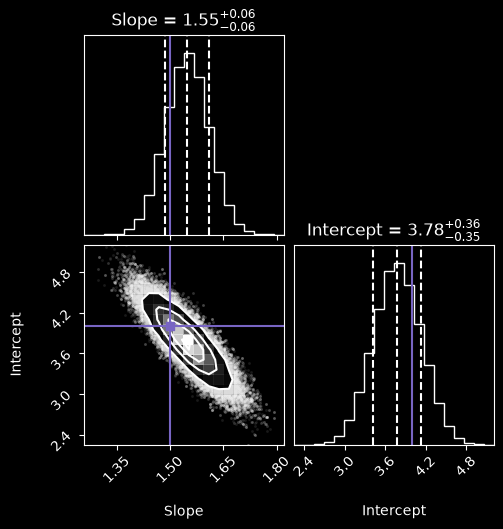

In [88]:
# reusing corner plot

corner.corner(
    bchain, # rpovides retianed posterior samples
    labels=["Slope", "Intercept"],
    truths=[slope_true, intercept_true], #usually unknown, so usually omitted
    truth_color="#7865C3",
    show_titles=True, #plot titles
    quantiles=[0.16, 0.50, 0.84] #requesting lines that correspond to this
)

plt.show()

(This is so cool.)

## Maximum Probability Sample

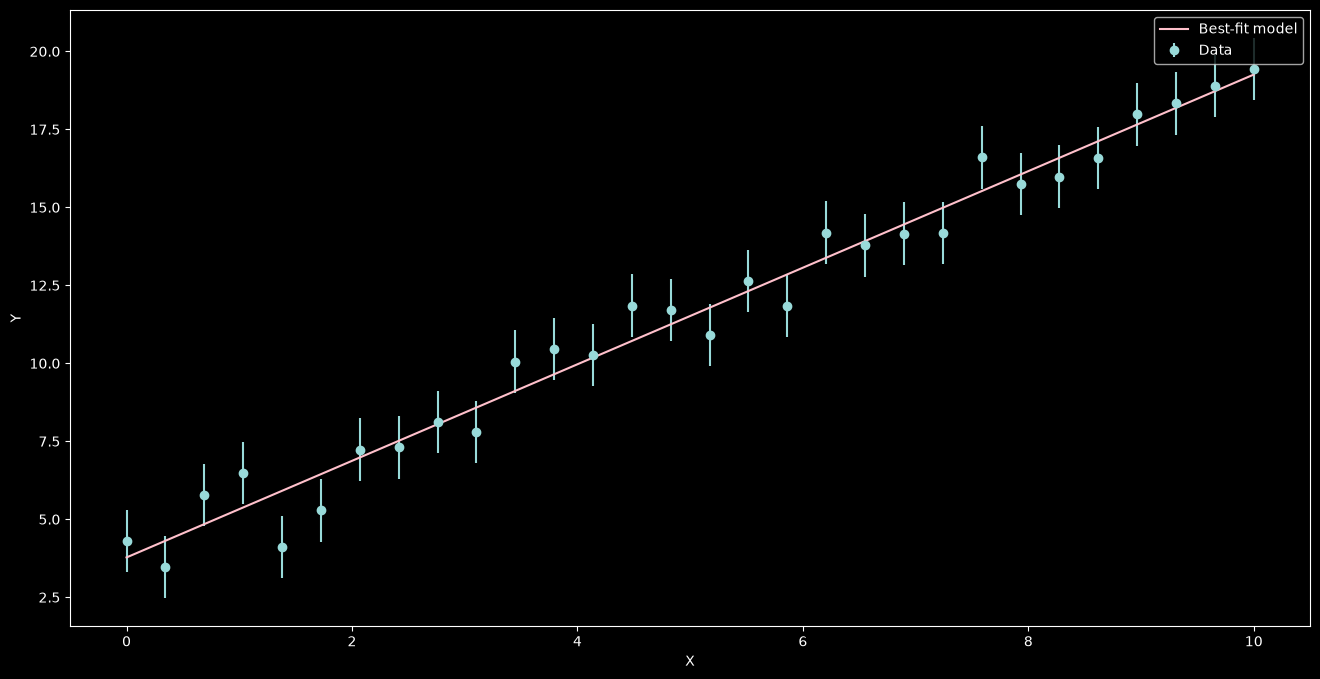

In [89]:
#finding best fit sample
flat_log_prob = sampler.get_log_prob(
    discard=burn_in,
    flat=True
) #retrieves log-probabilty from every retained sample
# settings must match bchain

best_index = np.argmax(flat_log_prob) #find index of largest log-probability
#np.argmax() returns position of the max value, not the actual max value
bestpar = bchain[best_index]
# retrieves the slope and intercept of the max-prob sample

#separating the parameter values
best_slope = bestpar[0]
best_intercept = bestpar[1]


best_model = best_slope * x + best_intercept

# plotting this
fig, ax = plt.subplots(figsize=(16, 8))

ax.errorbar(
    x,
    y,
    yerr=err,
    color = "#98DAD9",
    fmt="o",
    label="Data"
)

ax.plot(
    x,
    best_model,
    color = "pink",
    label="Best-fit model"
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.legend()

plt.show()


## Best fit vs. Posterior Median

Not always identical!!
- max-prob is the single sampled point with the highest posterior probability
- the posterior median is the middle of eahc maginalized parameter distribution

Median and percentile uncertainties is usually ore informative for reporting parameter measurements
Max-prob is good for making one representative best-fit model


## Plot models drawn from posterior
When many transparent lines overlap, darker regions show where the posterior predicts the model is most likely to lie.

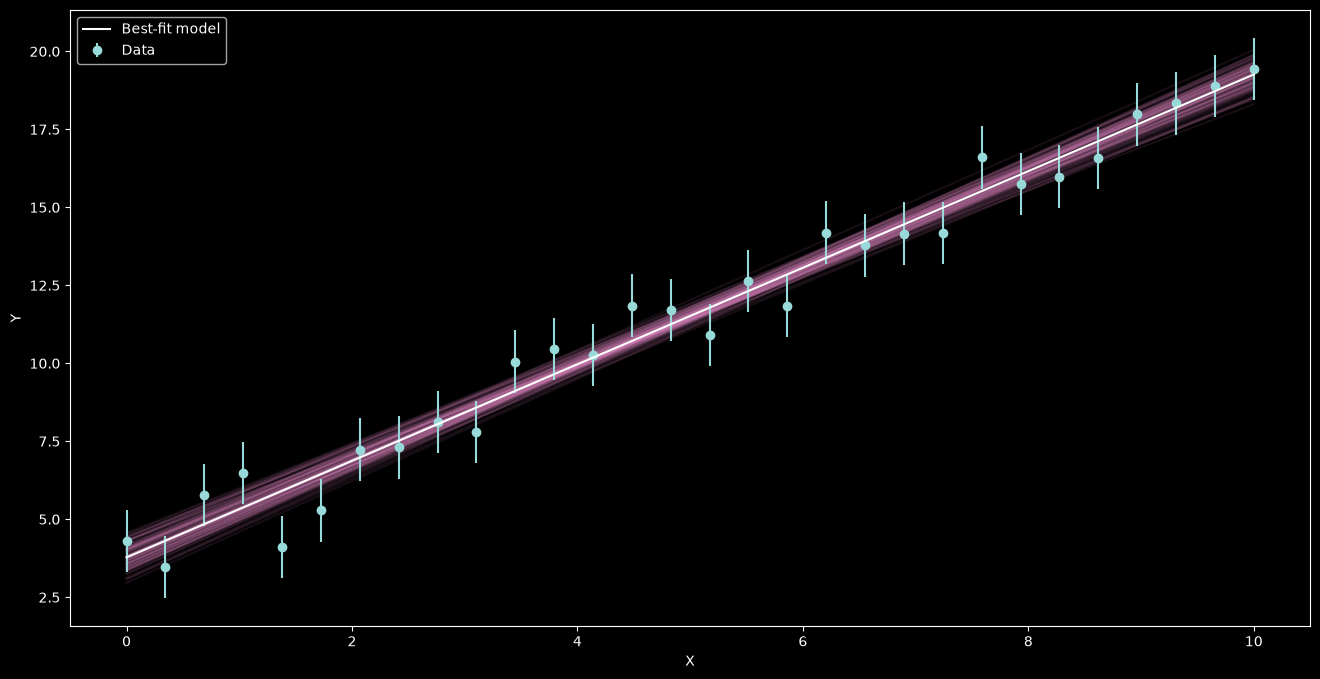

In [90]:
fig, ax = plt.subplots(figsize=(16, 8))

ax.errorbar(
    x, #horizontal coords
    y, # vertical coords
    yerr=err, #vertical uncertainties
    fmt="o", #observations = circular markers
    color = "#98DAD9",
    label="Data",
    zorder=2 #controls drawing layer
)

ax.plot(
    x,
    best_model,
    label="Best-fit model",
    color = "white",
    zorder=3
) 
# plots the predicted line calculated from the maximum-probability 
# slope and intercept.

#Randomly selects 100 indices from the posterior chain.
draws = rng.integers( #random integer selection
    0, #lowest index
    len(bchain), # number of posterior sampels as upper limit
    size=100 #100 random indices 
)


for draw in draws: #Loops through the 100 randomly selected posterior samples.
    slope_draw = bchain[draw, 0]
    intercept_draw = bchain[draw, 1]
    # retrieves the slope and intercept from one selected sample

    model_draw = slope_draw * x + intercept_draw
    # calculates the predicted line for that posterior sample

    ax.plot(
        x,
        model_draw,
        color="#E389C5", 
        alpha=0.1, #transparency
        zorder=1
    )

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.legend()

plt.show()

## Fitting a quadratic

You must install the tqdm library to use progress indicators with emcee


(5000, 32, 3)


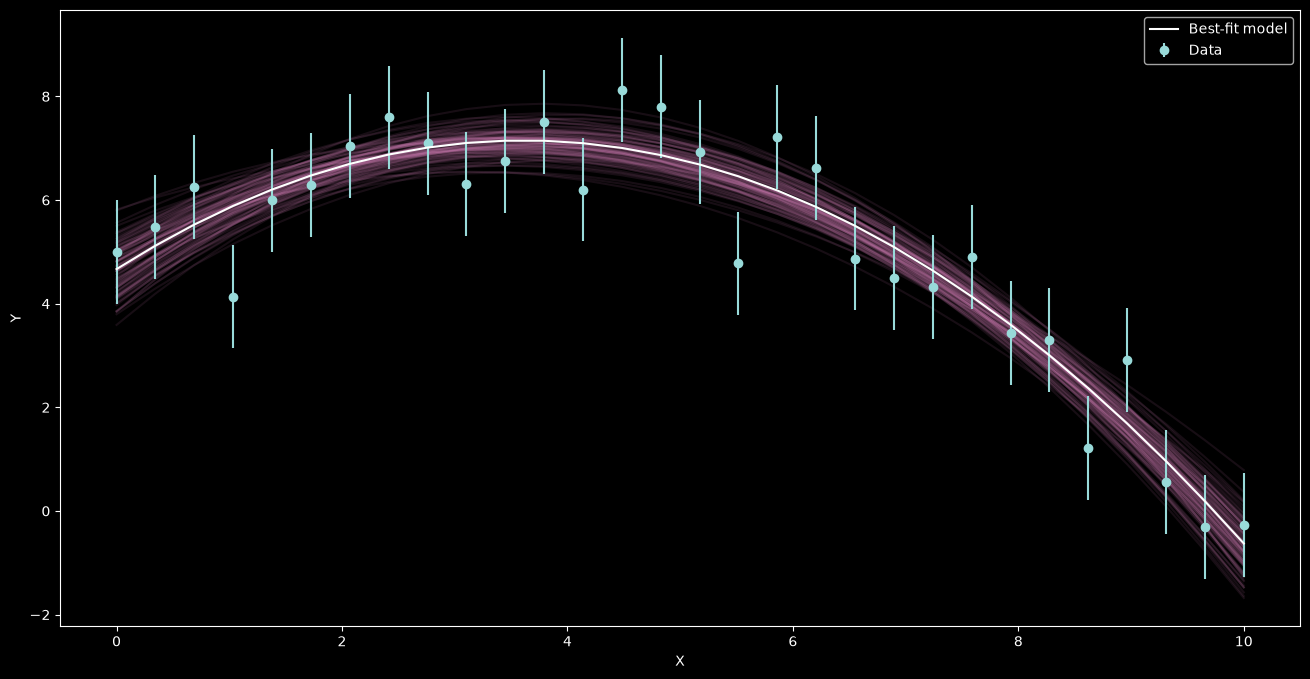

In [91]:
xnew = np.linspace(0, 10, 30)# generate an evenly sampled X axis 

slope_true = 1.5
intercept_true = 4
quadratic_true = -0.2
uncertainty_true = 1
ndim = 3 
nwalkers = 32
nsteps = 5000

#redefining new starting position
startpos = np.array([
    0,
    1,
    1
]) #initial guesses

ynew = quadratic_true * xnew**2 + slope_true * xnew + intercept_true 
ynew = ynew + np.random.normal(0, uncertainty_true, len(xnew)) 
 
errnew = np.ones_like(ynew) * uncertainty_true

def loglikelihood_quadratic(p, x, y, e):
    quadratic = p[0]
    slope = p[1]
    intercept = p[2]

    model = (
        quadratic * x**2
        + slope * x
        + intercept
    )

    chisq = np.sum((y - model)**2 / e**2)

    return -0.5 * chisq

def log_probability_quadratic(p, x, y, e):
    return loglikelihood_quadratic(p, x, y, e)

#making 3d walker positions
rng = np.random.default_rng(42)

initial_positions = (
    startpos
    + 1e-2 * rng.standard_normal((nwalkers, ndim))
)

#new sampler
sampler = emcee.EnsembleSampler(
    nwalkers,
    ndim,
    log_probability_quadratic,
    args=(xnew, ynew, errnew)
)

sampler.run_mcmc(
    initial_positions,
    nsteps,
    progress=True
)

chain = sampler.get_chain() #shape: (steps, walkers, 3)
print(chain.shape)

burn_in = 500

bchain = sampler.get_chain(
    discard=burn_in,
    flat = True
)

labels = [
    "Quadratic",
    "Slope",
    "Intercept"
]

fig, ax = plt.subplots(figsize=(16, 8))

#defining
flat_log_prob = sampler.get_log_prob(
    discard = burn_in,
    flat = True
)
best_index = np.argmax(flat_log_prob)
bestpar = bchain[best_index]
best_quadratic = bestpar[0]
best_slope = bestpar[1]
best_intercept = bestpar[2]

best_model = (
    best_quadratic * xnew**2 
    + best_slope * xnew 
    + best_intercept)

ax.errorbar(
    xnew, #horizontal coords
    ynew, # vertical coords
    yerr=errnew, #vertical uncertainties
    fmt="o", #observations = circular markers
    color = "#98DAD9",
    label="Data",
    zorder=2 #controls drawing layer
)

ax.plot(
    xnew,
    best_model,
    label="Best-fit model",
    color = "white",
    zorder=3
) 
# plots the predicted line calculated from the maximum-probability 
# slope and intercept.

#Randomly selects 100 indices from the posterior chain.
draws = rng.integers( #random integer selection
    0, #lowest index
    len(bchain), # number of posterior sampels as upper limit
    size=100 #100 random indices 
)


for draw in draws: #Loops through the 100 randomly selected posterior samples.
    quadratic_draw = bchain[draw, 0]
    slope_draw = bchain[draw, 1]
    intercept_draw = bchain[draw, 2]
    # retrieves the slope and intercept from one selected sample

    model_draw = (quadratic_draw * xnew**(2) 
    + slope_draw * xnew
    + intercept_draw)
    # calculates the predicted line for that posterior sample

    ax.plot(
        xnew,
        model_draw,
        color="#E389C5", 
        alpha=0.1, #transparency
        zorder=1
    )

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.legend()

plt.show()
